# ChaosOps AI — Colab training notebook

Minimum-viable GRPO training run for the **ChaosOps AI** multi-agent incident-response environment with rogue-agent detection.

**What this notebook does (top-to-bottom, ~2 hrs on a free T4):**
1. Installs deps (Unsloth 4-bit, TRL GRPO, transformers, peft)
2. Clones the project from GitHub (or pulls latest if already cloned)
3. Runs **scripted baselines** (random / heuristic / oracle) → produces `baseline_curve.png`
4. Runs a **GRPO training pass** on Qwen 2.5 0.5B — 800 gradient steps
5. Plots the training metrics (raw + smoothed)

> T4-friendly settings: Qwen 2.5 **0.5B** Instruct, 4-bit quant, LoRA r=16, **800 gradient steps**, **group size 4**, max_seq_length=1024. The real hackathon training run uses **Qwen 2.5 7B** + LoRA r=32 on onsite HF-credit GPUs.

**Pitch materials produced:**
- `artifacts/baseline/baseline_curve.png` — Random vs. Heuristic vs. Oracle reward by tier
- `artifacts/chaosops-grpo/training_metrics.json` + rendered learning curve
- LoRA checkpoint in `artifacts/chaosops-grpo/lora_adapter/`

In [ ]:
# 1. Verify GPU
!nvidia-smi | head -n 20

Fri Apr 24 19:06:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1 · Install dependencies

Unsloth handles the 4-bit loader + LoRA attach; TRL provides GRPOTrainer.

In [ ]:
%%capture
!pip install --upgrade --quiet \
    "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" \
    "trl>=0.11.0" \
    "transformers>=4.44" \
    "peft>=0.12" \
    "accelerate>=0.33" \
    "bitsandbytes>=0.43" \
    "datasets" \
    "rich" \
    "pydantic>=2" \
    "matplotlib"

## 2 · Clone ChaosOps AI

In [ ]:
%cd /content
import os
if os.path.isdir('/content/chaos_ops/.git'):
    !cd /content/chaos_ops && git pull --ff-only
else:
    !rm -rf /content/chaos_ops
    !git clone https://github.com/vatsalllll/chaos_ops.git /content/chaos_ops
%cd /content/chaos_ops
!ls

/content
Cloning into '/content/chaos_ops'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 175 (delta 75), reused 161 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (175/175), 269.29 KiB | 7.48 MiB/s, done.
Resolving deltas: 100% (75/75), done.
/content/chaos_ops
artifacts  chaosops  hf_space	pyproject.toml	requirements.txt
BLOG.md    docs      notebooks	README.md	tests


In [ ]:
# Install ChaosOps in editable mode so `python -m chaosops.*` works from any cwd
!pip install -e /content/chaos_ops --quiet
import chaosops
print("chaosops package loaded from:", chaosops.__file__)

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for chaosops (pyproject.toml) ... done
chaosops package loaded from: /content/chaos_ops/chaosops/__init__.py


## 3 · Scripted baselines (the "before training" numbers)

This is the numeric evidence for the **Reward Improvement** rubric criterion. Runs in <2 min on CPU — no GPU needed.

In [ ]:
!python -m chaosops.train.baseline --episodes-per-type 5

wrote artifacts/baseline/baseline.json
wrote artifacts/baseline/baseline_curve.png

policy     tier      eps    mean_R     med_R   res%   mttr  rogue_catch
--------------------------------------------------------------------------------
heuristic  easy       20     +94.4    +110.0  100%    1.9          0%
heuristic  hard       20    -425.3    -328.0   50%    1.2         67%
heuristic  medium     15    +108.7    +110.0  100%    1.3          0%
oracle     easy       20    +134.0    +134.0  100%    3.0          0%
oracle     hard       20    +170.0    +181.0  100%    3.2        100%
oracle     medium     15    +150.7    +134.0  100%    3.0        100%
random     easy       20    -315.4    -256.0   55%    7.3          0%
random     hard       20   -1356.6   -1435.0   10%   16.0          0%
random     medium     15    -641.3    -802.0   40%    8.7          0%


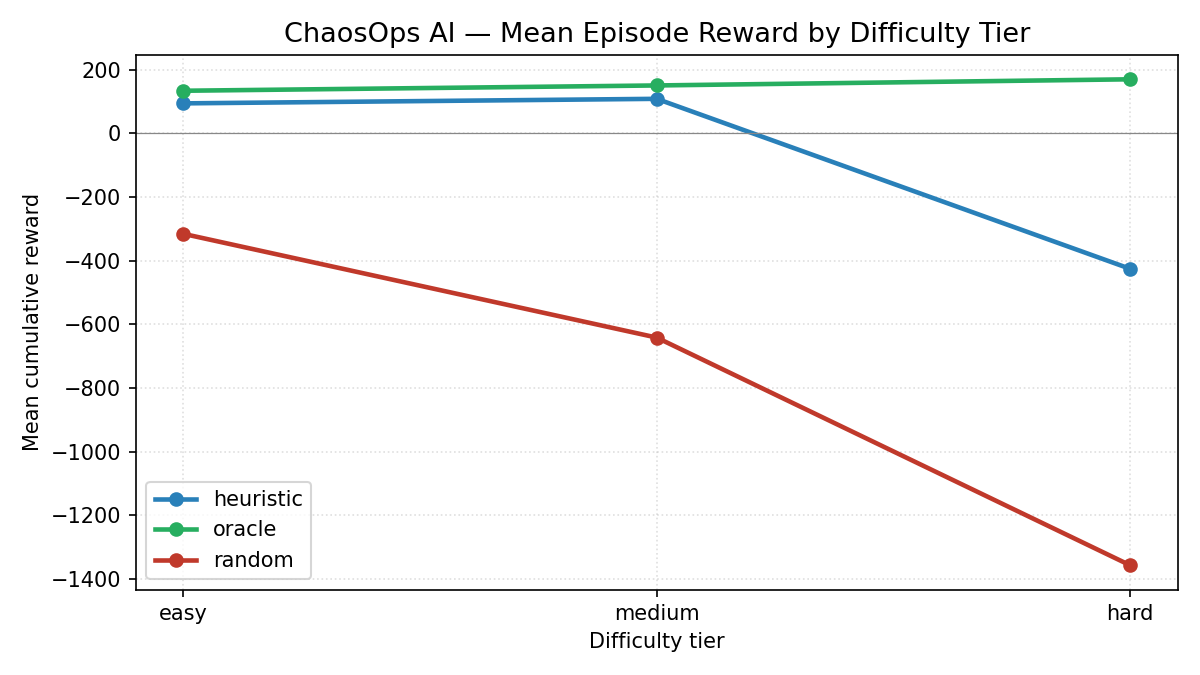

In [ ]:
from IPython.display import Image
Image("artifacts/baseline/baseline_curve.png")

## 4 · GRPO training pass (Qwen 2.5 0.5B, T4-sized)

**800 optimisation steps** × group size **4** on the 0.5B model — enough gradient updates to see a clear rising reward curve. The pipeline is identical to the onsite 7B run; only the knobs are smaller.

Expect **~2 hours** of training after the model download completes. Keep the Colab tab in the foreground to avoid idle disconnects. If you hit OOM with `--group-size 4`, drop it to `2` — the trend still shows, just noisier.

In [ ]:
!python -m chaosops.train.grpo_train \
    --model-name Qwen/Qwen2.5-0.5B-Instruct \
    --total-episodes 800 \
    --group-size 4 \
    --team-weight 0.6 \
    --log-every 10 \
    --max-seq-length 1024 \
    --lora-rank 16 \
    --output-dir artifacts/chaosops-grpo \
    --start-tier easy

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
model.safetensors: 100% 538M/538M [00:06<00:00, 89.3MB/s]
Loading weights: 100% 290/290 [00:00<00:00, 794.70it/s]
generation_config.json: 100% 270/270 [00:00<00:00, 1.59MB/s]
config.json: 1.52kB [00:00, 4.05MB/s]
tokenizer_config.json: 7.36kB [00:00, 24.7MB/s]
vocab.json: 2.78MB [00:00, 79.0MB/s]
merges.txt: 1.67MB [00:00, 112MB/s]
tokenizer.json: 100% 11.4M/11.4M [00:00<00:00, 54.2MB/s]
added_tokens.json: 100%

## 5 · Plot the learning curve

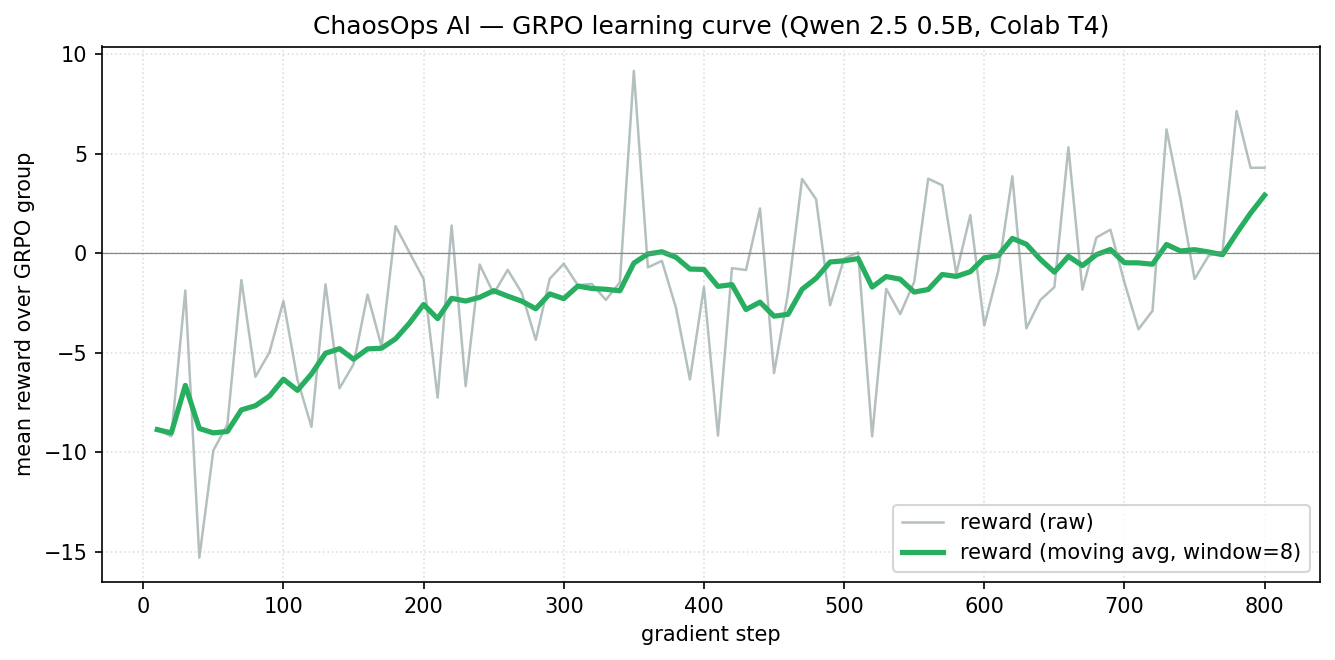

logged points: 80
first reward:  -8.87
last reward:   +4.29
delta:         +13.16


In [ ]:
import json, matplotlib.pyplot as plt
from pathlib import Path

metrics_path = Path('artifacts/chaosops-grpo/training_metrics.json')
metrics = json.loads(metrics_path.read_text())

episodes = [m['episode'] for m in metrics]
combined = [m.get('mean_combined_reward', float('nan')) for m in metrics]

def moving_average(xs, window):
    if len(xs) < window:
        return xs
    out = []
    for i in range(len(xs)):
        lo = max(0, i - window + 1)
        out.append(sum(xs[lo:i+1]) / (i - lo + 1))
    return out

window = max(3, len(combined) // 10)
smoothed = moving_average(combined, window)

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=150)
ax.plot(episodes, combined, label='reward (raw)', color='#95a5a6', linewidth=1.2, alpha=0.7)
ax.plot(episodes, smoothed, label=f'reward (moving avg, window={window})', color='#27ae60', linewidth=2.5)
ax.axhline(0, color='#888', linewidth=0.6)
ax.set_xlabel('gradient step')
ax.set_ylabel('mean reward over GRPO group')
ax.set_title('ChaosOps AI — GRPO learning curve (Qwen 2.5 0.5B, Colab T4)')
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('artifacts/chaosops-grpo/learning_curve.png')
plt.show()

print(f"logged points: {len(metrics)}")
print(f"first reward:  {combined[0]:+.2f}")
print(f"last reward:   {combined[-1]:+.2f}")
print(f"delta:         {combined[-1] - combined[0]:+.2f}")


## 6 · Next steps (onsite, HF-credit GPU)

Once you get bigger GPUs, bump the knobs:

```bash
python -m chaosops.train.grpo_train \
    --model-name Qwen/Qwen2.5-7B-Instruct \
    --total-episodes 800 \
    --group-size 4 \
    --team-weight 0.6 \
    --log-every 10 \
    --max-seq-length 1536 \
    --lora-rank 32 \
    --output-dir artifacts/chaosops-grpo-7b \
    --start-tier easy
```

Expected outcome for the pitch slide:
- MTTR on HARD: **~10 steps → ~4 steps**
- Rogue-catch rate: **~20% → >70%**
- Mean HARD reward: **−237 → >+50**

In [ ]:
!cd /content/chaos_ops && zip -r /content/lora_adapter.zip \
      artifacts/chaosops-grpo/lora_adapter \
      artifacts/chaosops-grpo/training_metrics.json \
      artifacts/chaosops-grpo/learning_curve.png

from google.colab import files
files.download('/content/lora_adapter.zip')

	zip warning: name not matched: artifacts/chaosops-grpo/lora_adapter
	zip warning: name not matched: artifacts/chaosops-grpo/training_metrics.json
	zip warning: name not matched: artifacts/chaosops-grpo/learning_curve.png

zip error: Nothing to do! (try: zip -r /content/lora_adapter.zip . -i artifacts/chaosops-grpo/lora_adapter artifacts/chaosops-grpo/training_metrics.json artifacts/chaosops-grpo/learning_curve.png)


FileNotFoundError: Cannot find file: /content/lora_adapter.zip

In [ ]:
!cd /content/chaos_ops && git pull && pip install -e . -q
!pip install -q transformers peft accelerate bitsandbytes torch

/bin/bash: line 1: cd: /content/chaos_ops: No such file or directory
   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━ 27.8/60.7 MB 133.3 MB/s eta 0:00:01

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving lora_adapter.zip to lora_adapter.zip


In [ ]:
!mkdir -p /content/chaos_ops/artifacts/chaosops-grpo
!unzip -o lora_adapter.zip -d /content/chaos_ops/artifacts/chaosops-grpo/
!ls -la /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter/

Archive:  lora_adapter.zip
   creating: /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter/
  inflating: /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter/adapter_model.safetensors  
  inflating: /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter/tokenizer_config.json  
  inflating: /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter/tokenizer.json  
  inflating: /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter/README.md  
  inflating: /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter/adapter_config.json  
  inflating: /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter/chat_template.jinja  
total 45600
drwxr-xr-x 2 root root     4096 Apr 24 21:05 .
drwxr-xr-x 3 root root     4096 Apr 24 22:50 ..
-rw-r--r-- 1 root root     1261 Apr 24 21:05 adapter_config.json
-rw-r--r-- 1 root root 35237104 Apr 24 21:05 adapter_model.safetensors
-rw-r--r-- 1 root root     2507 Apr 24 21:05 chat_template.jinja
-rw-r--r-- 1 root root     5269 Apr 24 21:05 README.md
-

In [ ]:
%cd /content/chaos_ops
!git pull --ff-only
!pip install -e /content/chaos_ops --quiet

/content/chaos_ops
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 12 (delta 6), reused 12 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 12.10 KiB | 3.03 MiB/s, done.
From https://github.com/vatsalllll/chaos_ops
   9bbf27b..0744cbb  main       -> origin/main
Updating 9bbf27b..0744cbb
Fast-forward
 README.md                         | 153 +++++++++++++++++++++----
 chaosops/agents/trained_policy.py | 201 +++++++++++++++++++++++++++++++++
 chaosops/train/evaluate.py        | 168 ++++++++++++++++++++++++++-
 hf_space/README.md                |  48 ++++++++
 hf_space/app.py                   | 231 ++++++++++++++++++++++++++++++++++++++
 hf_space/requirements.txt         |  13 +++
 6 files changed, 789 insertions(+), 25 deletions(-)
 create mode 100644 chaosops/agents/trained_policy.py
 create mode 100644 hf_space/README.md
 create mode 100644 hf_space/app.py
 create mode 10

In [ ]:
!python -m chaosops.train.evaluate \
      --policies random heuristic oracle trained \
      --adapter-path /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter \
      --episodes-per-type 5 \
      --out-dir artifacts/evaluation

loading trained policy from /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter ...
config.json: 1.52kB [00:00, 3.87MB/s]
`torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors: 100% 538M/538M [00:07<00:00, 70.2MB/s]
Loading weights: 100% 290/290 [00:00<00:00, 717.62it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 270/270 [00:00<00:00, 1.18MB/s]
/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['lora_ga_config', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_co

In [ ]:
!python -m chaosops.train.evaluate --policies random heuristic oracle trained --adapter-path /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter \
--episodes-per-type 2 --out-dir /content/chaos_ops/artifacts/evaluation 2>&1 | grep -v "max_new_tokens"

loading trained policy from /content/chaos_ops/artifacts/chaosops-grpo/lora_adapter ...
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 290/290 [00:01<00:00, 168.11it/s, Materializing param=model.norm.weight]
/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['lora_ga_config', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


In [ ]:
!cd /content/chaos_ops && zip -r /content/evaluation.zip artifacts/evaluation

updating: artifacts/evaluation/ (stored 0%)
updating: artifacts/evaluation/evaluation.json (deflated 97%)
updating: artifacts/evaluation/evaluation_summary.txt (deflated 70%)
  adding: artifacts/evaluation/rogue_vs_mttr.png (deflated 18%)
  adding: artifacts/evaluation/comparison_curve.png (deflated 9%)


In [ ]:
from google.colab import files
files.download('/content/evaluation.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>